In [57]:
# ==========================================
# CELL 1 — IMPORT LIBRARIES & LOAD DATASET
# ==========================================

import pandas as pd
import numpy as np

column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
    'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','class','difficulty'
]

train_df = pd.read_csv(r"C:\Users\yasha\Downloads\nsl-kdd\KDDTrain+.txt", header=None, names=column_names)
test_df  = pd.read_csv(r"C:\Users\yasha\Downloads\nsl-kdd\KDDTest+.txt", header=None, names=column_names)

train_df.drop("difficulty", axis=1, inplace=True)
test_df.drop("difficulty", axis=1, inplace=True)

print(train_df.shape, test_df.shape)


(125973, 42) (22544, 42)


In [4]:
# ==========================================
# CELL 2 — CREATE BINARY TARGET + PREPARE INPUTS
# ==========================================

train_df['attack_binary'] = (train_df['class'] != 'normal').astype(int)
test_df['attack_binary']  = (test_df['class'] != 'normal').astype(int)

y_train = train_df['attack_binary']
y_test  = test_df['attack_binary']

X_train_raw = train_df.drop(['class', 'attack_binary'], axis=1)
X_test_raw  = test_df.drop(['class', 'attack_binary'], axis=1)

categorical_cols = ["protocol_type", "service", "flag"]
numerical_cols   = [c for c in X_train_raw.columns if c not in categorical_cols]


In [5]:
# ==========================================
# CELL 3 — ONE-HOT ENCODING
# ==========================================

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ohe = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
], remainder="passthrough")

X_train_ohe = ohe.fit_transform(X_train_raw)
X_test_ohe  = ohe.transform(X_test_raw)

print("OHE Shapes:", X_train_ohe.shape, X_test_ohe.shape)


OHE Shapes: (125973, 122) (22544, 122)


In [6]:
# ==========================================
# CELL 4 — SCALE NUMERICAL FEATURES
# ==========================================

from sklearn.preprocessing import StandardScaler

num_start = X_train_ohe.shape[1] - len(numerical_cols)
scaler = StandardScaler(with_mean=False)

X_train_scaled = X_train_ohe.copy()
X_test_scaled  = X_test_ohe.copy()

X_train_scaled[:, num_start:] = scaler.fit_transform(X_train_ohe[:, num_start:])
X_test_scaled[:, num_start:]  = scaler.transform(X_test_ohe[:, num_start:])


In [50]:
print("X_train_scaled shape =", X_train_scaled.shape)
print("X_test_scaled shape = ", X_test_scaled.shape)

print("y_train shape =", y_train.shape)
print("y_test shape =", y_test.shape)


X_train_scaled shape = (125973, 122)
X_test_scaled shape =  (22544, 122)
y_train shape = (125973,)
y_test shape = (22544,)


In [41]:
# ==============================
# CELL 5 — DEFINE TUNED MODELS 
# ==============================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

tuned_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=4000,
        C=0.5,
        solver="lbfgs",
        n_jobs=-1,
        class_weight="balanced"
    ),

    "Linear SVM": LinearSVC(
        C=0.7,
        max_iter=8000,
        class_weight="balanced",
        tol=1e-4
    ),

    "Naive Bayes": GaussianNB(
        var_smoothing=1e-9
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=18,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=450,
        max_depth=28,
        min_samples_split=3,
        min_samples_leaf=2,
        bootstrap=True,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}


In [42]:
# ==========================================
# CELL 6 — TRAIN & EVALUATE TUNED MODELS
# ==========================================

print("\n===== TUNED MODELS (ONE-HOT ENCODING, NO SMOTE) =====\n")

from sklearn.metrics import accuracy_score, classification_report

for name, model in tuned_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    print("Accuracy:", round(accuracy_score(y_test, preds), 4))
    print(classification_report(y_test, preds, target_names=["Normal", "Attack"]))



===== TUNED MODELS (ONE-HOT ENCODING, NO SMOTE) =====


Training Logistic Regression...
Accuracy: 0.7531
              precision    recall  f1-score   support

      Normal       0.65      0.93      0.76      9711
      Attack       0.92      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544


Training Linear SVM...
Accuracy: 0.7528
              precision    recall  f1-score   support

      Normal       0.65      0.92      0.76      9711
      Attack       0.92      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544


Training Naive Bayes...
Accuracy: 0.5664
              precision    recall  f1-score   support

      Normal       0.50      0.99      0.66      9711
      Attack       0.98      0.24      0.39     

In [33]:
from category_encoders import MEstimateEncoder
from sklearn.preprocessing import StandardScaler

categorical_cols_TE = ['protocol_type', 'service', 'flag']

# Create encoder
te_encoder = MEstimateEncoder(cols=categorical_cols_TE, m=5)

# Fit on raw data (NOT OHE)
te_encoder.fit(X_train_raw, y_train)

# Transform
X_train_TE = te_encoder.transform(X_train_raw)
X_test_TE  = te_encoder.transform(X_test_raw)

print("Target Encoding Done!")


Target Encoding Done!


In [34]:
numerical_cols_TE = [col for col in X_train_raw.columns if col not in categorical_cols_TE]

scaler_TE = StandardScaler()

X_train_TE[numerical_cols_TE] = scaler_TE.fit_transform(X_train_TE[numerical_cols_TE])
X_test_TE[numerical_cols_TE] = scaler_TE.transform(X_test_TE[numerical_cols_TE])


In [43]:
print("\n===== MODELS USING TARGET ENCODING =====\n")

models_TE = {
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=350, learning_rate=0.05, max_depth=4),
    "XGBoost": XGBClassifier(
        n_estimators=600, learning_rate=0.05, max_depth=9,
        subsample=0.8, colsample_bytree=0.8, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(
        n_estimators=600, num_leaves=70, learning_rate=0.04, class_weight="balanced"),
    "CatBoost": CatBoostClassifier(
        iterations=600, depth=8, learning_rate=0.05, loss_function='Logloss', eval_metric='Accuracy', verbose=False
),
}

from sklearn.metrics import accuracy_score, classification_report

for name, model in models_TE.items():
    print(f"\nTraining {name} ...")
    model.fit(X_train_TE, y_train)
    preds = model.predict(X_test_TE)

    print(f"{name} Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(classification_report(y_test, preds, target_names=["Normal","Attack"]))



===== MODELS USING TARGET ENCODING =====


Training Gradient Boosting ...
Gradient Boosting Accuracy: 0.8059
              precision    recall  f1-score   support

      Normal       0.70      0.97      0.81      9711
      Attack       0.97      0.68      0.80     12833

    accuracy                           0.81     22544
   macro avg       0.83      0.83      0.81     22544
weighted avg       0.85      0.81      0.80     22544


Training XGBoost ...
XGBoost Accuracy: 0.8036
              precision    recall  f1-score   support

      Normal       0.69      0.97      0.81      9711
      Attack       0.97      0.68      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544


Training LightGBM ...
[LightGBM] [Info] Number of positive: 58630, number of negative: 67343
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011112 

In [ ]:
# ============================================================
# TRAIN + TEST METRICS FOR ALL MODELS (OHE + TARGET ENCODING)
# BINARY CLASSIFICATION
# ============================================================

from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
import pandas as pd
import numpy as np


def get_metrics(model, X, y):
    preds = model.predict(X)

    # Probability or decision score for AUC
    try:
        probs = model.predict_proba(X)[:, 1]

    except:
        try:
            scores = model.decision_function(X)

            # LinearSVC returns 1D scores → normalize safely
            if scores.ndim == 1:
                probs = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
            else:
                probs = scores[:, 1]

        except:
            probs = None

    accuracy = accuracy_score(y, preds)
    sensitivity = recall_score(y, preds)

    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    specificity = tn / (tn + fp)

    f1 = f1_score(y, preds)
    auc = roc_auc_score(y, probs) if probs is not None else np.nan

    return accuracy, sensitivity, specificity, f1, auc



# ============================================================
# LISTS TO STORE RESULTS
# ============================================================

train_rows = []
test_rows = []


# ============================================================
# PART 1 — OHE MODELS 
# ============================================================

for name, model in tuned_models.items():

    model.fit(X_train_scaled, y_train)

    # TRAIN metrics
    tr_acc, tr_sens, tr_spec, tr_f1, tr_auc = get_metrics(
        model, X_train_scaled, y_train
    )
    train_rows.append([
        name + " (OHE)",
        f"{tr_acc*100:.2f}%",
        f"{tr_sens*100:.2f}%",
        f"{tr_spec*100:.2f}%",
        f"{tr_f1*100:.2f}%",
        f"{tr_auc:.4f}" if not np.isnan(tr_auc) else "NA"
    ])

    # TEST metrics
    te_acc, te_sens, te_spec, te_f1, te_auc = get_metrics(
        model, X_test_scaled, y_test
    )
    test_rows.append([
        name + " (OHE)",
        f"{te_acc*100:.2f}%",
        f"{te_sens*100:.2f}%",
        f"{te_spec*100:.2f}%",
        f"{te_f1*100:.2f}%",
        f"{te_auc:.4f}" if not np.isnan(te_auc) else "NA"
    ])



# ============================================================
# PART 2 — TARGET ENCODING MODELS
# ============================================================

for name, model in models_TE.items():

    # TRAIN metrics
    tr_acc, tr_sens, tr_spec, tr_f1, tr_auc = get_metrics(
        model, X_train_TE, y_train
    )
    train_rows.append([
        name + " (TE)",
        f"{tr_acc*100:.2f}%",
        f"{tr_sens*100:.2f}%",
        f"{tr_spec*100:.2f}%",
        f"{tr_f1*100:.2f}%",
        f"{tr_auc:.4f}" if not np.isnan(tr_auc) else "NA"
    ])

    # TEST metrics
    te_acc, te_sens, te_spec, te_f1, te_auc = get_metrics(
        model, X_test_TE, y_test
    )
    test_rows.append([
        name + " (TE)",
        f"{te_acc*100:.2f}%",
        f"{te_sens*100:.2f}%",
        f"{te_spec*100:.2f}%",
        f"{te_f1*100:.2f}%",
        f"{te_auc:.4f}" if not np.isnan(te_auc) else "NA"
    ])


# ============================================================
# CREATE FINAL TABLES
# ============================================================

train_df_metrics = pd.DataFrame(train_rows, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
]).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

test_df_metrics = pd.DataFrame(test_rows, columns=[
    "Model", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "AUC"
]).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)


# ============================================================
# DISPLAY 
# ============================================================

print("\nTRAIN METRICS (BINARY — ALL MODELS)\n")
display(train_df_metrics)

print("\nTEST METRICS (BINARY — ALL MODELS)\n")
display(test_df_metrics)



TRAIN METRICS (BINARY — ALL MODELS)



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,XGBoost (TE),99.99%,99.99%,100.00%,99.99%,1.0000
1,LightGBM (TE),99.99%,100.00%,99.99%,99.99%,1.0000
2,Random Forest (OHE),99.95%,99.92%,99.97%,99.94%,1.0000
3,Decision Tree (OHE),99.94%,99.97%,99.92%,99.94%,1.0000
4,CatBoost (TE),99.94%,99.90%,99.97%,99.94%,1.0000
5,Gradient Boosting (TE),99.90%,99.86%,99.94%,99.90%,1.0000
6,Linear SVM (OHE),97.40%,96.70%,98.01%,97.19%,0.9965
7,Logistic Regression (OHE),97.37%,96.67%,97.98%,97.16%,0.9965
8,Naive Bayes (OHE),85.87%,69.91%,99.78%,82.16%,0.9796



TEST METRICS (BINARY — ALL MODELS)



,Model,Accuracy,Sensitivity,Specificity,F1 Score,AUC
0,Decision Tree (OHE),83.00%,75.00%,93.56%,83.39%,0.8537
1,Gradient Boosting (TE),80.59%,67.84%,97.44%,79.92%,0.9603
2,XGBoost (TE),80.36%,67.64%,97.18%,79.68%,0.9649
3,LightGBM (TE),80.03%,67.03%,97.20%,79.26%,0.9614
4,CatBoost (TE),77.84%,63.17%,97.22%,76.45%,0.9609
5,Random Forest (OHE),76.60%,60.91%,97.34%,74.77%,0.9668
6,Logistic Regression (OHE),75.31%,62.28%,92.51%,74.17%,0.8008
7,Linear SVM (OHE),75.28%,62.31%,92.43%,74.16%,0.7867
8,Naive Bayes (OHE),56.64%,24.37%,99.28%,39.02%,0.7992



=== ONE-HOT ENCODING — Confusion Matrices & ROC Curves ===



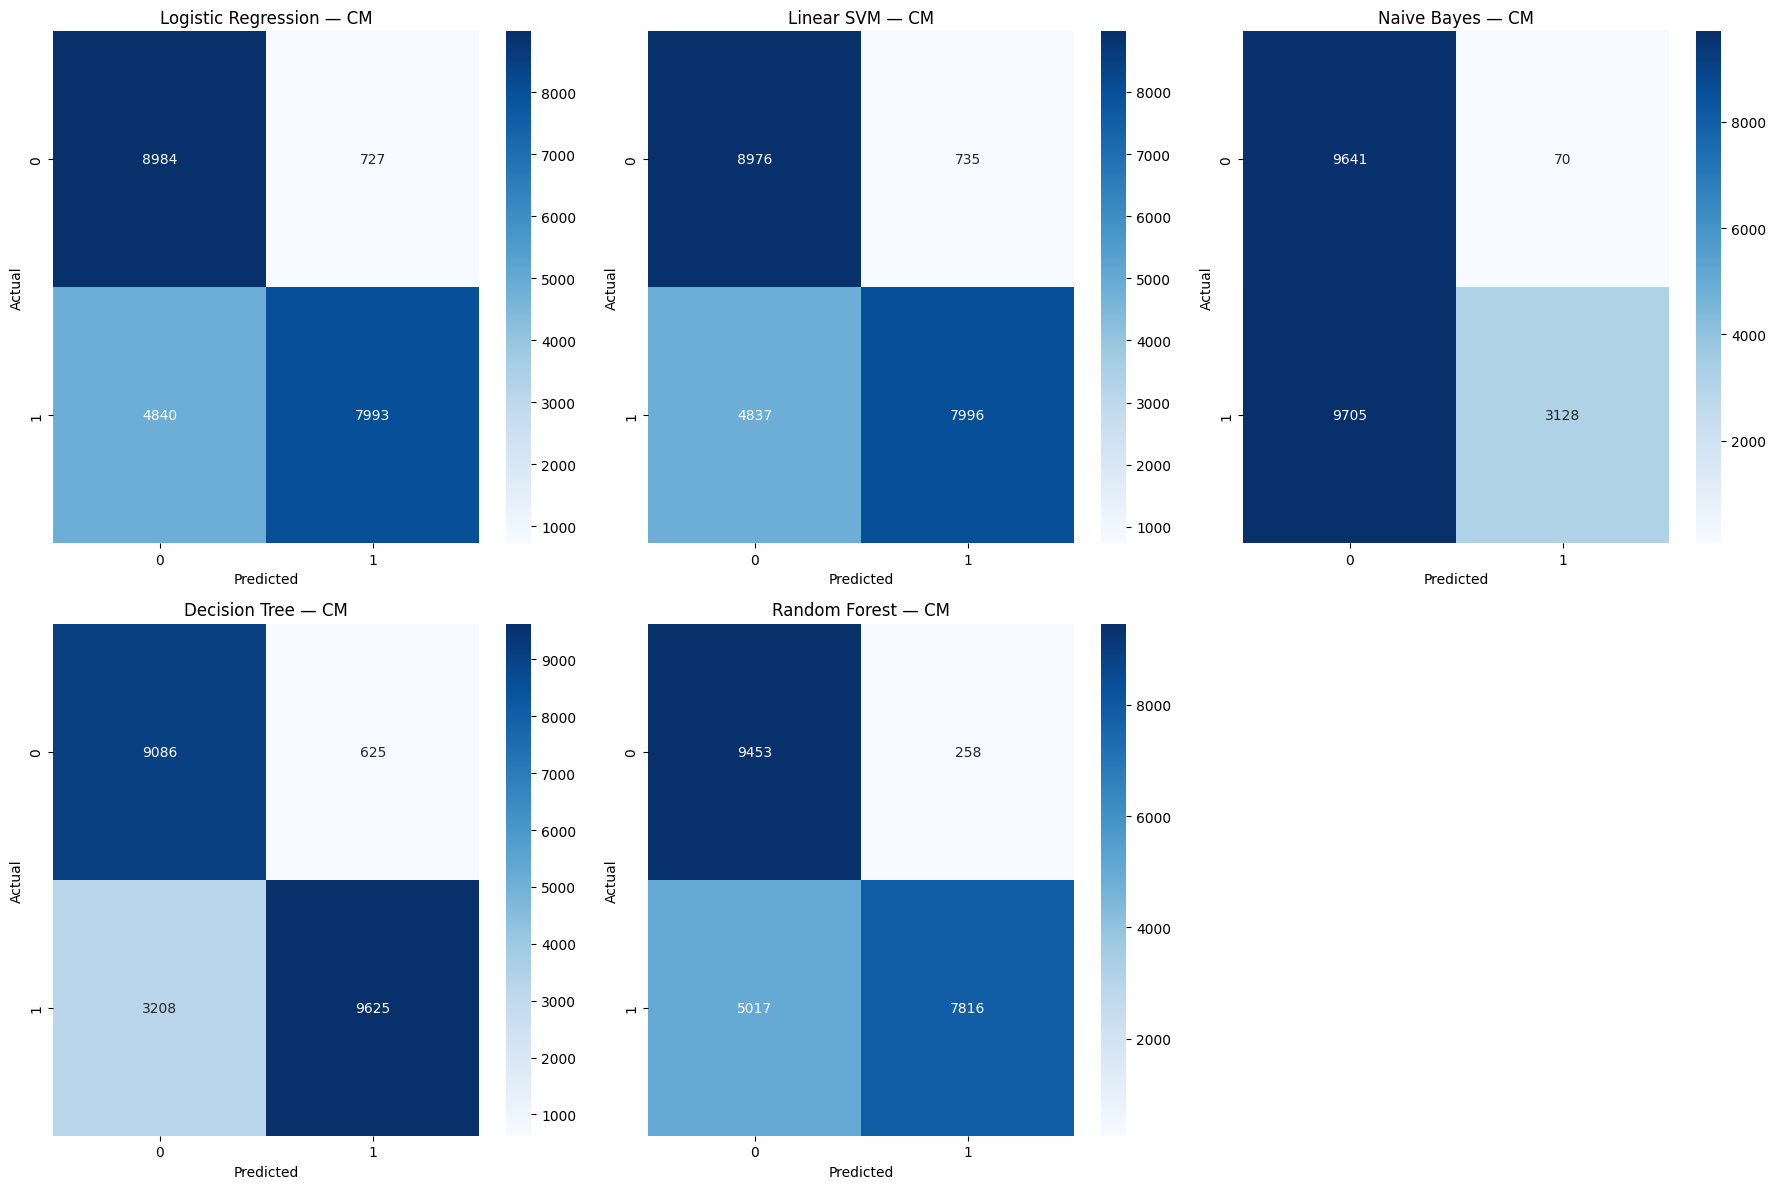

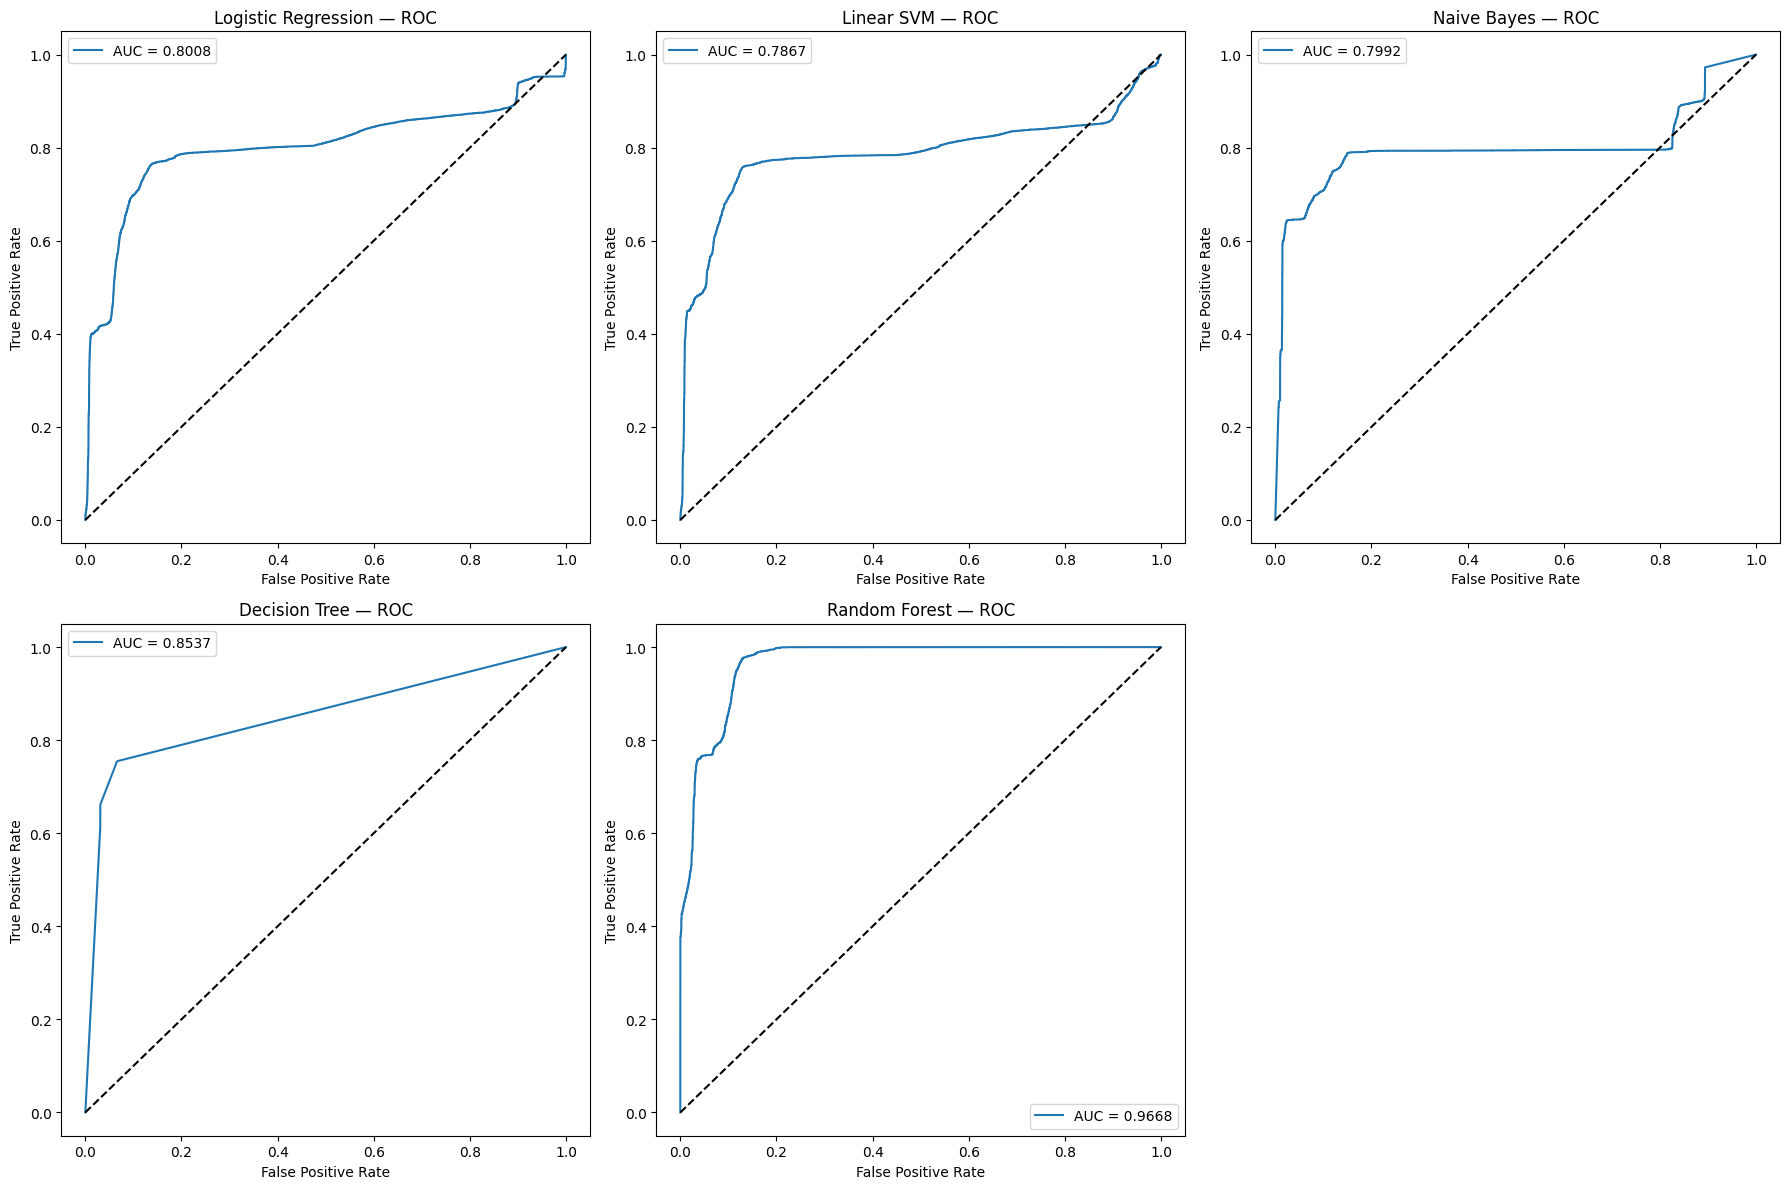


=== TARGET ENCODING — Confusion Matrices & ROC Curves ===



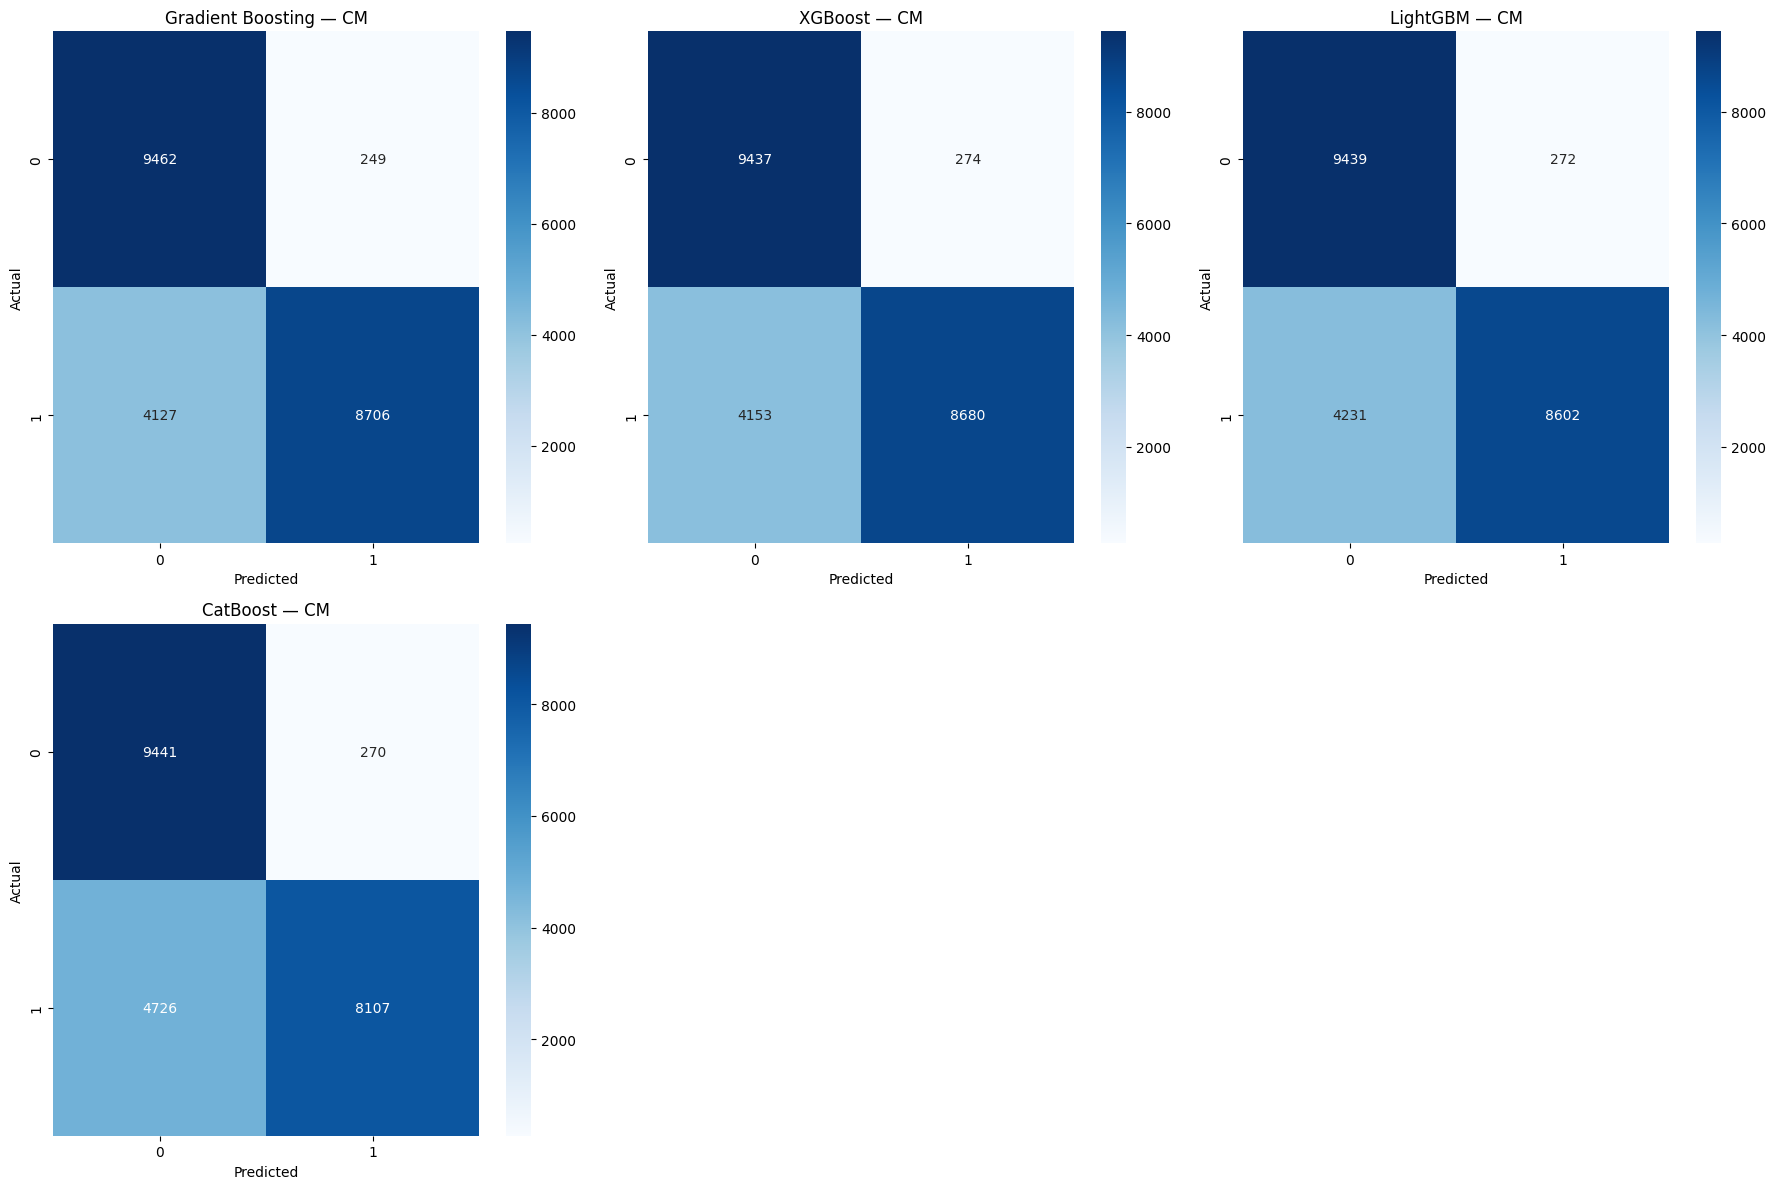

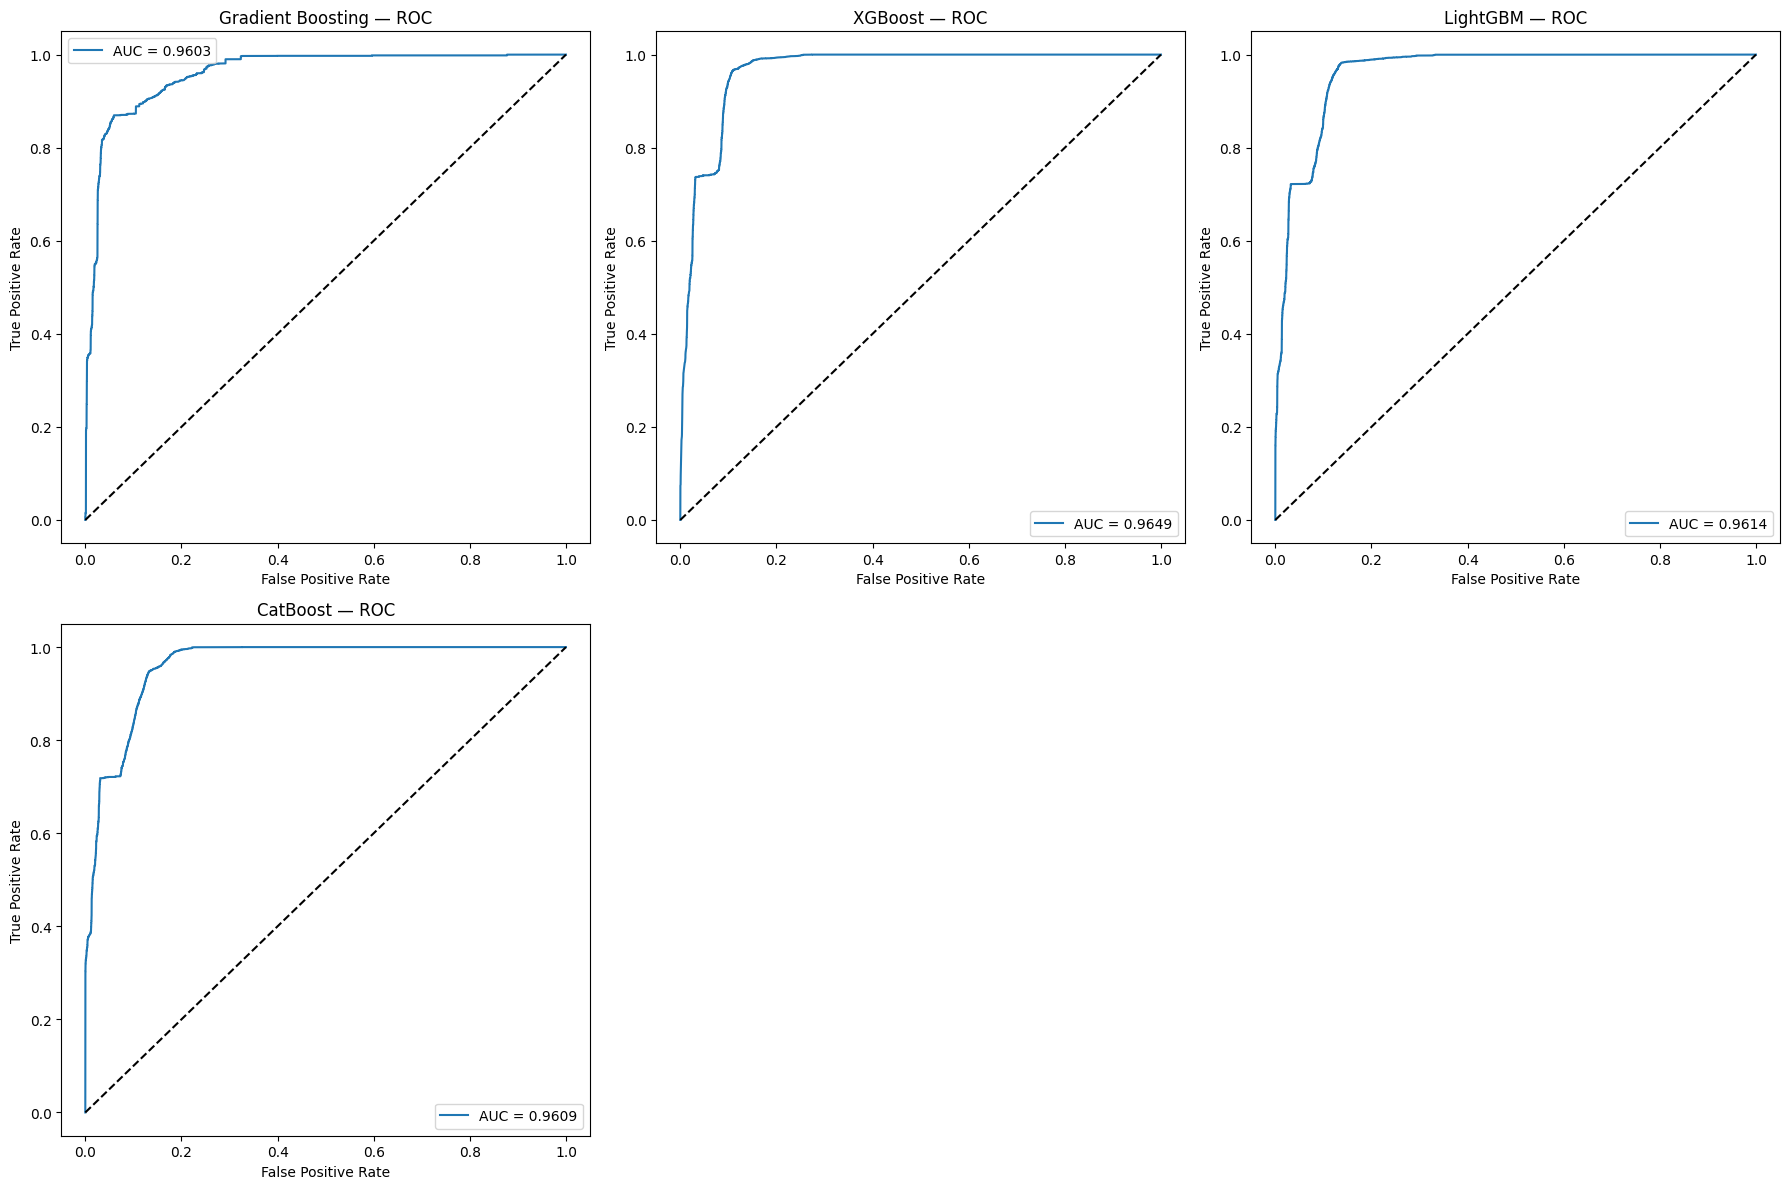

In [ ]:
# =============================================
# CONFUSION MATRICES, ROC CURVES 
# =============================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

def plot_cm_roc(models_dict, X_test, y_test, encoding_name):
    print(f"\n=== {encoding_name} — Confusion Matrices & ROC Curves ===\n")
    
    model_names = list(models_dict.keys())
    n = len(model_names)

    # ---------------------------
    # CONFUSION MATRICES
    # ---------------------------
    rows = (n + 2) // 3
    plt.figure(figsize=(18, 6 * rows))

    for i, (name, model) in enumerate(models_dict.items()):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)

        plt.subplot(rows, 3, i + 1)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"{name} — CM")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

    # ---------------------------
    # ROC CURVES
    # ---------------------------
    plt.figure(figsize=(18, 6 * rows))

    for i, (name, model) in enumerate(models_dict.items()):
        # get probability
        try:
            probs = model.predict_proba(X_test)[:, 1]
        except:
            try:
                scores = model.decision_function(X_test)
                if scores.ndim == 1:
                    probs = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
                else:
                    probs = scores[:, 1]
            except:
                probs = None

        if probs is not None:
            fpr, tpr, _ = roc_curve(y_test, probs)
            roc_auc = auc(fpr, tpr)
        else:
            fpr, tpr, roc_auc = [0, 1], [0, 1], 0.5

        plt.subplot(rows, 3, i + 1)
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.title(f"{name} — ROC")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()

    plt.tight_layout()
    plt.show()


# =============================================
# CALL FUNCTION FOR BOTH ENCODINGS
# =============================================

# 1) ONE-HOT ENCODING MODELS
plot_cm_roc(tuned_models, X_test_scaled, y_test, "ONE-HOT ENCODING")

# 2) TARGET ENCODING MODELS
plot_cm_roc(models_TE, X_test_TE, y_test, "TARGET ENCODING")


In [58]:
# ============================
# MULTI-CLASS LABEL CREATION
# ============================

def map_attack(label):
    if label == "normal":
        return "normal"
    elif label in ["apache2","back","land","neptune","mailbomb","pod",
                   "processtable","smurf","teardrop","udpstorm","worm"]:
        return "dos"
    elif label in ["ipsweep","mscan","nmap","portsweep","saint","satan"]:
        return "probe"
    elif label in ["ftp_write","guess_passwd","http_tunnel","imap","multihop",
                   "named","phf","sendmail","snmpgetattack","snmpguess","spy",
                   "warezclient","warezmaster","xlock","xsnoop"]:
        return "r2l"
    else:
        return "u2r"

train_df["attack_class"] = train_df["class"].apply(map_attack)
test_df["attack_class"]  = test_df["class"].apply(map_attack)

from sklearn.preprocessing import LabelEncoder
le_mc = LabelEncoder()

y_train_mc = le_mc.fit_transform(train_df["attack_class"])
y_test_mc  = le_mc.transform(test_df["attack_class"])

class_names_mc = le_mc.classes_
print("Classes:", class_names_mc)


Classes: ['dos' 'normal' 'probe' 'r2l' 'u2r']


In [69]:
# ============================================
# CELL 2 — SPLIT FEATURES FOR MULTICLASS
# ============================================

X_train_mc_raw = train_df.drop(["class", "attack_class"], axis=1)
X_test_mc_raw  = test_df.drop(["class", "attack_class"], axis=1)

print("Train features:", X_train_mc_raw.shape)
print("Test features:",  X_test_mc_raw.shape)


Train features: (125973, 41)
Test features: (22544, 41)


In [ ]:
# ============================================
# CELL 2 — SPLIT FEATURES FOR MULTICLASS
# ============================================

X_train_mc_raw = train_df.drop(["class", "attack_class"], axis=1)
X_test_mc_raw  = test_df.drop(["class", "attack_class"], axis=1)

print("Train features:", X_train_mc_raw.shape)
print("Test features:",  X_test_mc_raw.shape)


OHE Shapes: (125973, 122) (22544, 122)


In [70]:
# ============================================
# CELL 3 — MULTICLASS ONE-HOT ENCODING (OHE)
# ============================================

from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

categorical_cols_mc = ["protocol_type", "service", "flag"]
numerical_cols_mc = [c for c in X_train_mc_raw.columns if c not in categorical_cols_mc]

# One-hot encoder
ohe_mc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Encode categorical
X_train_mc_cat = ohe_mc.fit_transform(X_train_mc_raw[categorical_cols_mc])
X_test_mc_cat  = ohe_mc.transform(X_test_mc_raw[categorical_cols_mc])

# Scale numerical
scaler_mc = StandardScaler()
X_train_mc_num = scaler_mc.fit_transform(X_train_mc_raw[numerical_cols_mc])
X_test_mc_num  = scaler_mc.transform(X_test_mc_raw[numerical_cols_mc])

# Combine
X_train_mc_ohe = np.hstack([X_train_mc_num, X_train_mc_cat])
X_test_mc_ohe  = np.hstack([X_test_mc_num, X_test_mc_cat])

print("OHE shapes:", X_train_mc_ohe.shape, X_test_mc_ohe.shape)


OHE shapes: (125973, 122) (22544, 122)


In [71]:
# ============================================
# CELL 4 — MULTICLASS TARGET ENCODING (TE)
# ============================================

from category_encoders import MEstimateEncoder

te_mc = MEstimateEncoder(cols=categorical_cols_mc, m=5)
te_mc.fit(X_train_mc_raw, y_train_mc)

X_train_mc_te = te_mc.transform(X_train_mc_raw)
X_test_mc_te  = te_mc.transform(X_test_mc_raw)

# Scale only numeric columns
scaler_te_mc = StandardScaler()
X_train_mc_te[numerical_cols_mc] = scaler_te_mc.fit_transform(X_train_mc_te[numerical_cols_mc])
X_test_mc_te[numerical_cols_mc]  = scaler_te_mc.transform(X_test_mc_te[numerical_cols_mc])

print("TE shapes:", X_train_mc_te.shape, X_test_mc_te.shape)


TE shapes: (125973, 41) (22544, 41)


In [ ]:
# ============================================================
# ALL MODELS (OHE + TARGET ENCODING) — FINAL LIST
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# --------------------------
# ONE-HOT ENCODING MODELS
# --------------------------

models_OHE = {

    "Logistic Regression (OHE)": LogisticRegression(
        max_iter=4000,
        C=0.5,
        solver="lbfgs",
        n_jobs=-1,
        class_weight="balanced"
    ),

    "Linear SVM (OHE)": LinearSVC(
        C=0.7,
        max_iter=8000,
        class_weight="balanced",
        tol=1e-4
    ),

    "Naive Bayes (OHE)": GaussianNB(
        var_smoothing=1e-9
    ),

    "Decision Tree (OHE)": DecisionTreeClassifier(
        max_depth=18,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest (OHE)": RandomForestClassifier(
        n_estimators=450,
        max_depth=28,
        min_samples_split=3,
        min_samples_leaf=2,
        bootstrap=True,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

# --------------------------
# TARGET ENCODING MODELS
# --------------------------

models_TE = {

    "Gradient Boosting (TE)": GradientBoostingClassifier(
        n_estimators=350,
        learning_rate=0.05,
        max_depth=4
    ),

    "XGBoost (TE)": XGBClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=9,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
    ),

    "LightGBM (TE)": LGBMClassifier(
        objective="multiclass",
        num_class=5,
        n_estimators=600,
        learning_rate=0.04,
        num_leaves=70,
        class_weight="balanced",
        min_gain_to_split=0.01,
        random_state=42
),

    "CatBoost (TE)": CatBoostClassifier(
        iterations=600,
        depth=8,
        learning_rate=0.05,
        loss_function='MultiClass',
        eval_metric='MultiClass',
        verbose=False,
        random_seed=42
    )
}

print("All models loaded!")


All models loaded!


In [73]:
# ============================================
# CELL 4 — TRAIN MULTICLASS MODELS
# ============================================

from sklearn.metrics import accuracy_score, classification_report

print("\n===== TRAINING MULTICLASS MODELS (OHE) =====\n")
for name, model in models_OHE.items():
    print("\nTraining:", name)
    model.fit(X_train_mc_ohe, y_train_mc)
    preds = model.predict(X_test_mc_ohe)
    print(f"{name} Accuracy: {accuracy_score(y_test_mc, preds):.4f}")
    print(classification_report(y_test_mc, preds, target_names=class_names_mc))



===== TRAINING MULTICLASS MODELS (OHE) =====


Training: Logistic Regression (OHE)
Logistic Regression (OHE) Accuracy: 0.7920
              precision    recall  f1-score   support

         dos       0.92      0.83      0.87      7460
      normal       0.74      0.91      0.82      9711
       probe       0.82      0.86      0.84      2421
         r2l       0.87      0.24      0.38      2752
         u2r       0.08      0.17      0.11       200

    accuracy                           0.79     22544
   macro avg       0.69      0.60      0.60     22544
weighted avg       0.82      0.79      0.78     22544


Training: Linear SVM (OHE)
Linear SVM (OHE) Accuracy: 0.7489
              precision    recall  f1-score   support

         dos       0.92      0.79      0.85      7460
      normal       0.69      0.92      0.79      9711
       probe       0.70      0.68      0.69      2421
         r2l       0.71      0.12      0.20      2752
         u2r       0.07      0.13      0.09       2

In [77]:
print("\n===== TRAINING MULTICLASS MODELS (TE) =====\n")
for name, model in models_TE.items():
    print("\nTraining:", name)
    model.fit(X_train_mc_te, y_train_mc)
    preds = model.predict(X_test_mc_te)
    print(f"{name} Accuracy: {accuracy_score(y_test_mc, preds):.4f}")
    print(classification_report(y_test_mc, preds, target_names=class_names_mc))



===== TRAINING MULTICLASS MODELS (TE) =====


Training: Gradient Boosting (TE)
Gradient Boosting (TE) Accuracy: 0.7739
              precision    recall  f1-score   support

         dos       0.96      0.82      0.89      7460
      normal       0.68      0.97      0.80      9711
       probe       0.82      0.75      0.78      2421
         r2l       0.94      0.02      0.03      2752
         u2r       0.71      0.07      0.14       200

    accuracy                           0.77     22544
   macro avg       0.82      0.53      0.53     22544
weighted avg       0.82      0.77      0.73     22544


Training: XGBoost (TE)
XGBoost (TE) Accuracy: 0.7738
              precision    recall  f1-score   support

         dos       0.96      0.84      0.90      7460
      normal       0.68      0.97      0.80      9711
       probe       0.80      0.67      0.73      2421
         r2l       0.97      0.05      0.09      2752
         u2r       0.62      0.03      0.05       200

    accurac

In [81]:
# ============================================================
# MULTICLASS METRICS TABLE (TRAIN + TEST)
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Metric function for MULTICLASS
# ------------------------------------------------------------
def get_mc_metrics(model, X, y_true):
    preds = model.predict(X)

    acc  = accuracy_score(y_true, preds)
    prec = precision_score(y_true, preds, average="macro", zero_division=0)
    rec  = recall_score(y_true, preds, average="macro", zero_division=0)
    f1   = f1_score(y_true, preds, average="macro", zero_division=0)

    return acc, prec, rec, f1


train_rows_mc = []
test_rows_mc  = []


# ============================================================
# 1️⃣ OHE MODELS (Already Trained)
# ============================================================

for name, model in models_OHE.items():
    
    model.fit(X_train_mc_ohe, y_train_mc)

    # TRAIN metrics
    tr_acc, tr_prec, tr_rec, tr_f1 = get_mc_metrics(
        model, X_train_mc_ohe, y_train_mc
    )
    train_rows_mc.append([
        name,
        f"{tr_acc*100:.2f}%",
        f"{tr_prec*100:.2f}%",
        f"{tr_rec*100:.2f}%",
        f"{tr_f1*100:.2f}%"
    ])

    # TEST metrics
    te_acc, te_prec, te_rec, te_f1 = get_mc_metrics(
        model, X_test_mc_ohe, y_test_mc
    )
    test_rows_mc.append([
        name,
        f"{te_acc*100:.2f}%",
        f"{te_prec*100:.2f}%",
        f"{te_rec*100:.2f}%",
        f"{te_f1*100:.2f}%"
    ])


# ============================================================
# 2️⃣ TARGET ENCODING MODELS (Already Trained)
# ============================================================

for name, model in models_TE.items():

    # TRAIN metrics
    tr_acc, tr_prec, tr_rec, tr_f1 = get_mc_metrics(
        model, X_train_mc_te, y_train_mc
    )
    train_rows_mc.append([
        name,
        f"{tr_acc*100:.2f}%",
        f"{tr_prec*100:.2f}%",
        f"{tr_rec*100:.2f}%",
        f"{tr_f1*100:.2f}%"
    ])

    # TEST metrics
    te_acc, te_prec, te_rec, te_f1 = get_mc_metrics(
        model, X_test_mc_te, y_test_mc
    )
    test_rows_mc.append([
        name,
        f"{te_acc*100:.2f}%",
        f"{te_prec*100:.2f}%",
        f"{te_rec*100:.2f}%",
        f"{te_f1*100:.2f}%"
    ])


# ============================================================
# CREATE FINAL TABLES
# ============================================================

train_df_mc = pd.DataFrame(train_rows_mc, columns=[
    "Model", "Accuracy", "Precision (Macro)", "Recall (Macro)", "F1 Score (Macro)"
]).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

test_df_mc = pd.DataFrame(test_rows_mc, columns=[
    "Model", "Accuracy", "Precision (Macro)", "Recall (Macro)", "F1 Score (Macro)"
]).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)


# ============================================================
# DISPLAY TABLES
# ============================================================

print("\n======== MULTICLASS TRAIN METRICS ========\n")
display(train_df_mc)

print("\n======== MULTICLASS TEST METRICS ========\n")
display(test_df_mc)


[LightGBM] [Warning] min_gain_to_split is set=0.01, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.01
[LightGBM] [Warning] min_gain_to_split is set=0.01, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.01

======== MULTICLASS TRAIN METRICS ========



,Model,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
0,XGBoost (TE),99.99%,100.00%,99.61%,99.80%
1,LightGBM (TE),99.99%,99.62%,100.00%,99.81%
2,Random Forest (OHE),99.95%,96.80%,99.98%,98.30%
3,CatBoost (TE),99.93%,98.68%,96.80%,97.71%
4,Gradient Boosting (TE),99.87%,85.54%,85.98%,85.73%
5,Decision Tree (OHE),99.65%,91.64%,99.87%,95.20%
6,Linear SVM (OHE),97.95%,72.65%,90.11%,77.53%
7,Logistic Regression (OHE),96.46%,65.46%,97.27%,69.85%
8,Naive Bayes (OHE),69.50%,55.58%,65.16%,41.01%



======== MULTICLASS TEST METRICS ========



,Model,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro)
0,Logistic Regression (OHE),79.20%,68.58%,60.43%,60.30%
1,Gradient Boosting (TE),77.39%,82.30%,52.70%,52.77%
2,XGBoost (TE),77.38%,80.84%,51.08%,51.37%
3,LightGBM (TE),76.96%,83.70%,53.55%,54.26%
4,CatBoost (TE),75.86%,84.52%,50.88%,52.12%
5,Linear SVM (OHE),74.89%,61.98%,52.85%,52.55%
6,Random Forest (OHE),74.64%,79.11%,48.92%,50.30%
7,Decision Tree (OHE),73.48%,66.54%,50.33%,49.04%
8,Naive Bayes (OHE),47.37%,51.00%,36.80%,33.52%



===  OHE MODELS  ===


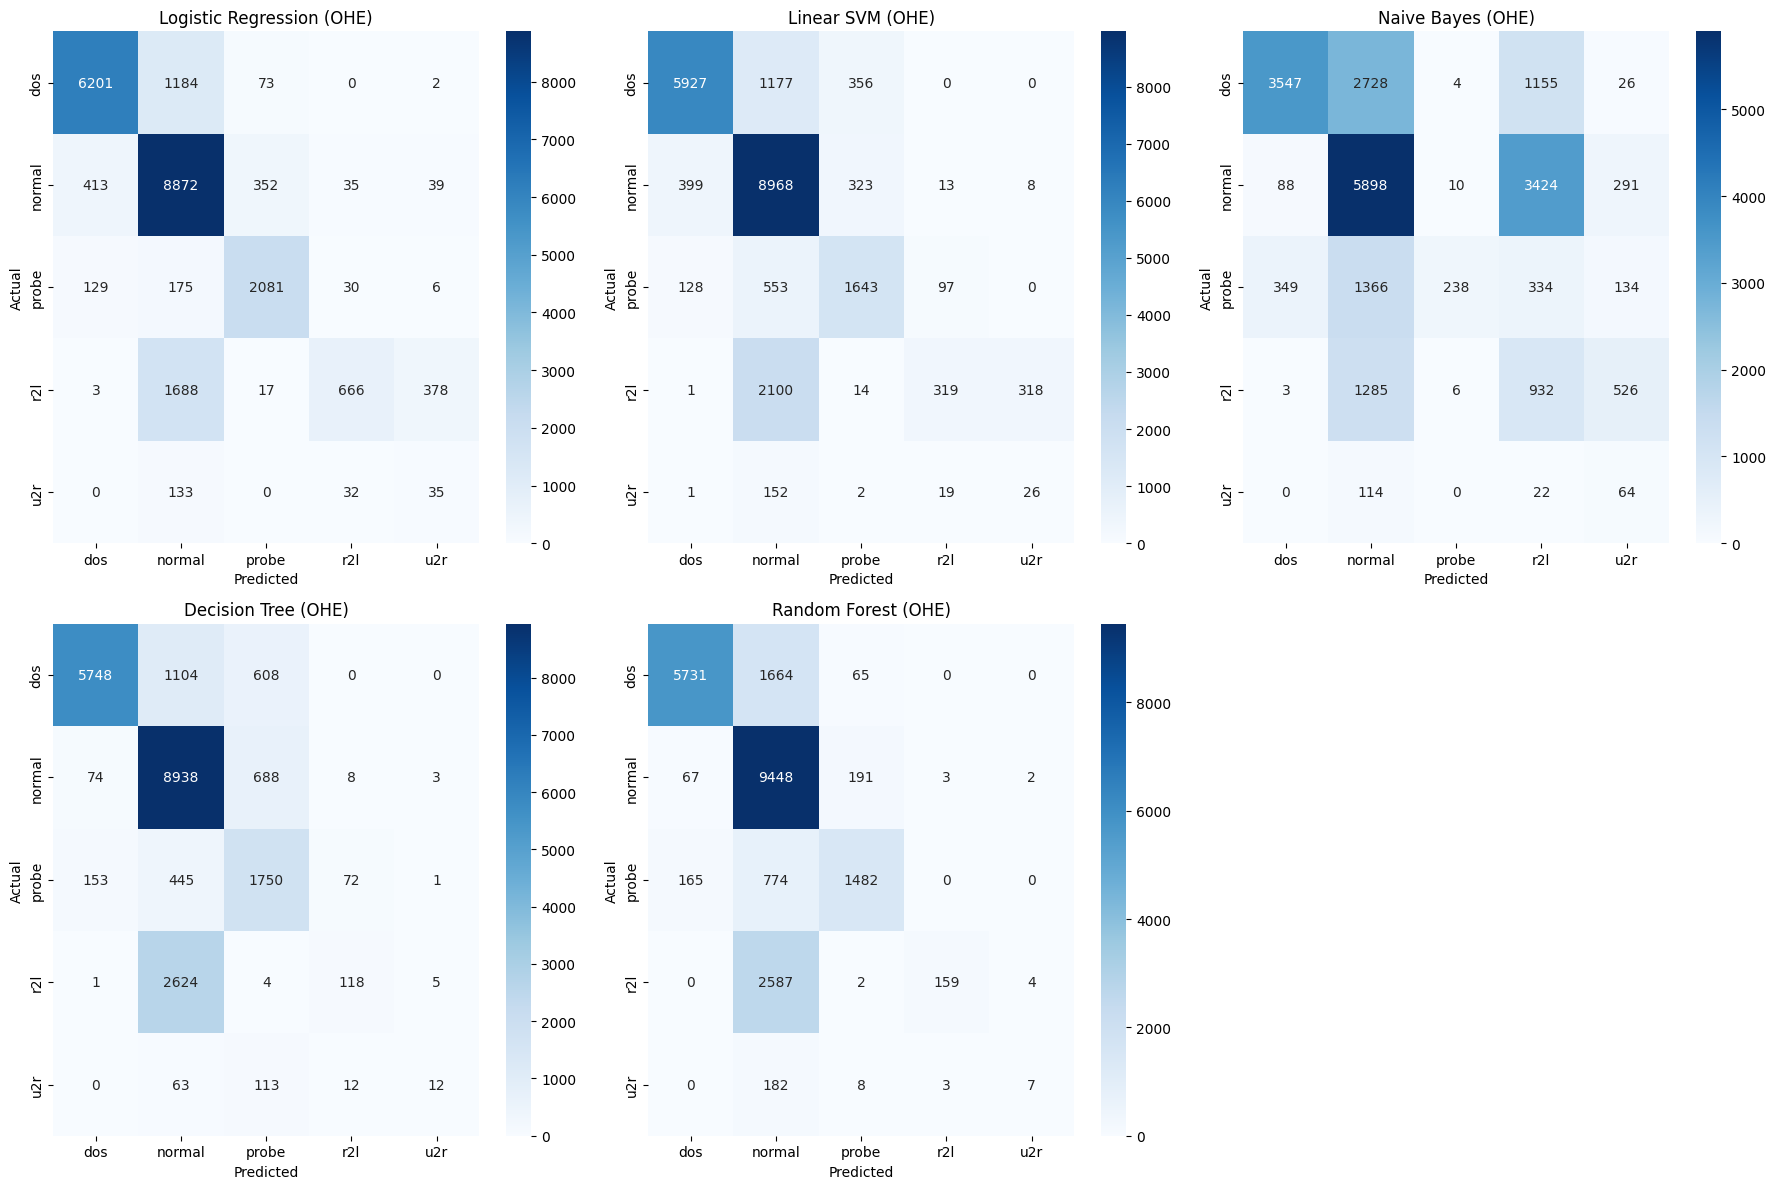

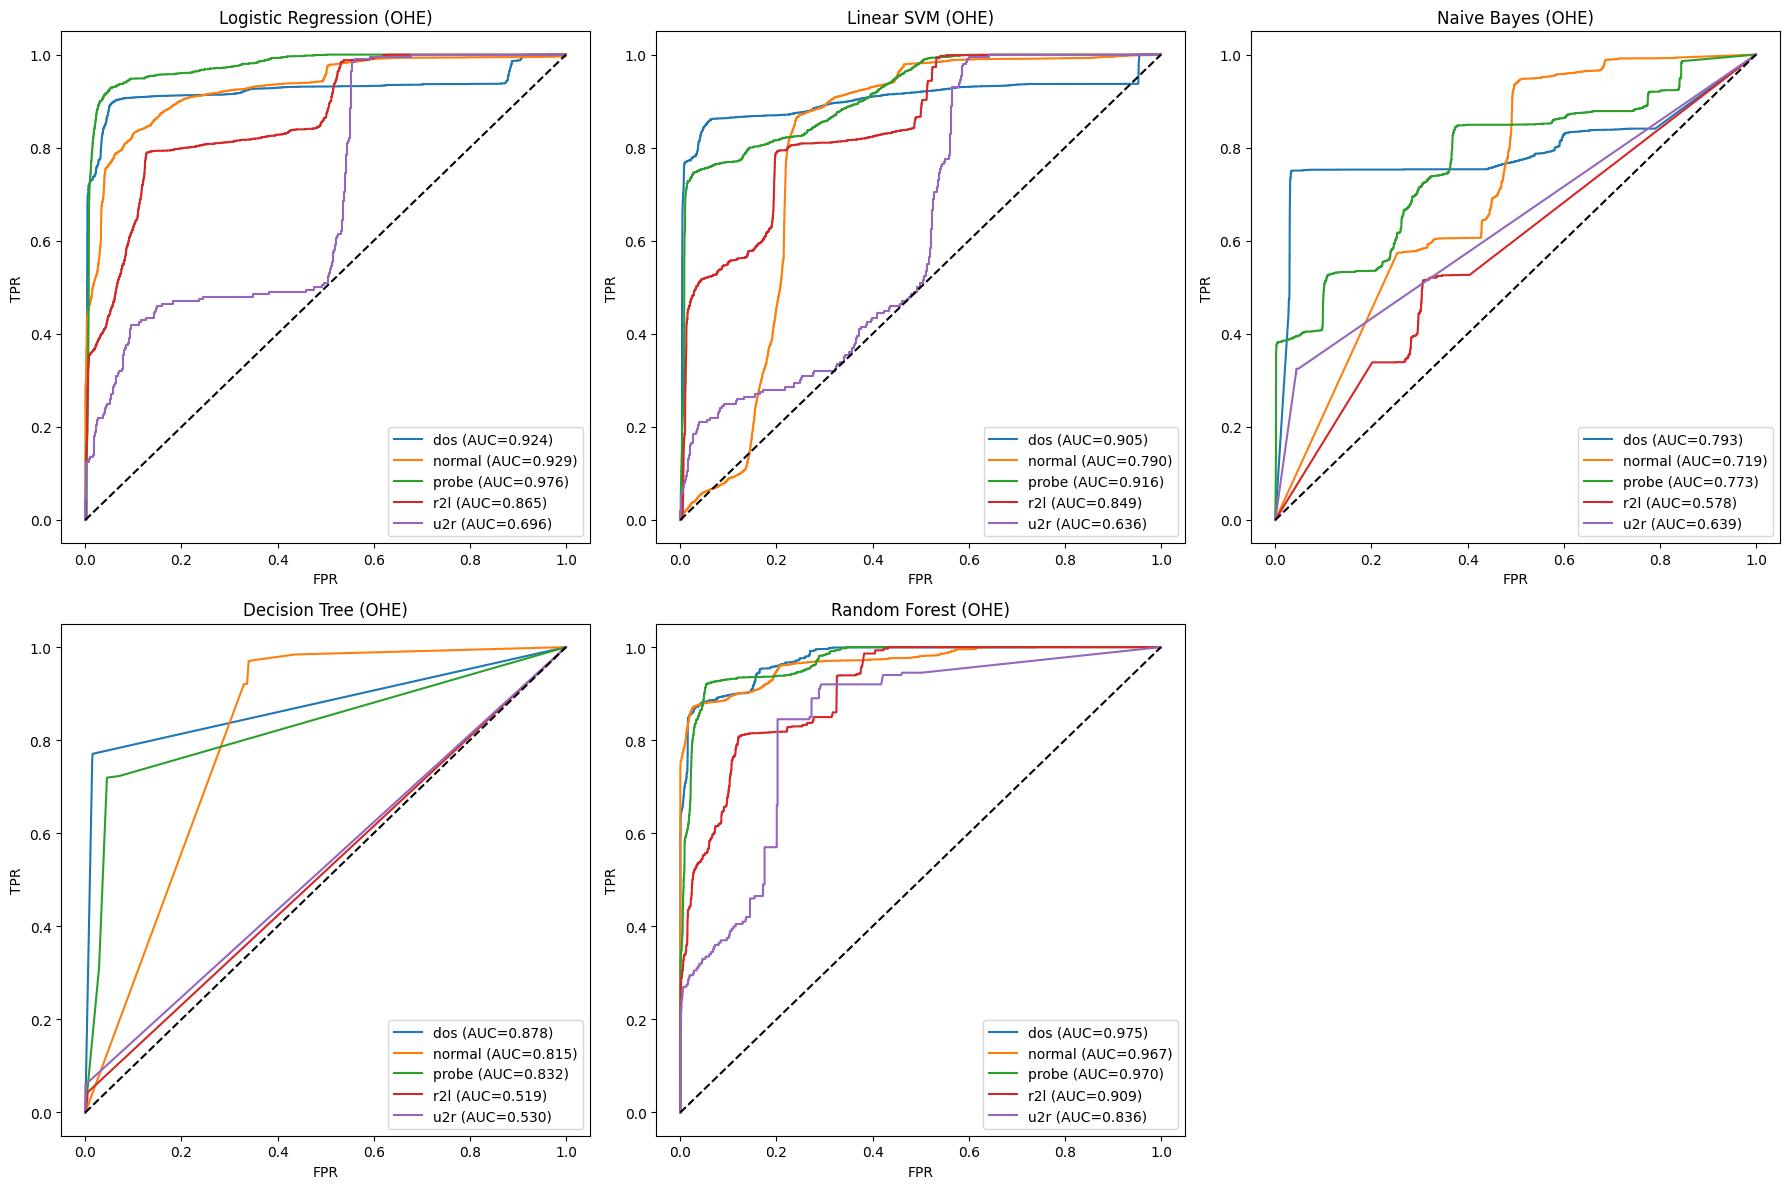


===  TARGET ENCODING MODELS  ===
[LightGBM] [Warning] min_gain_to_split is set=0.01, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.01


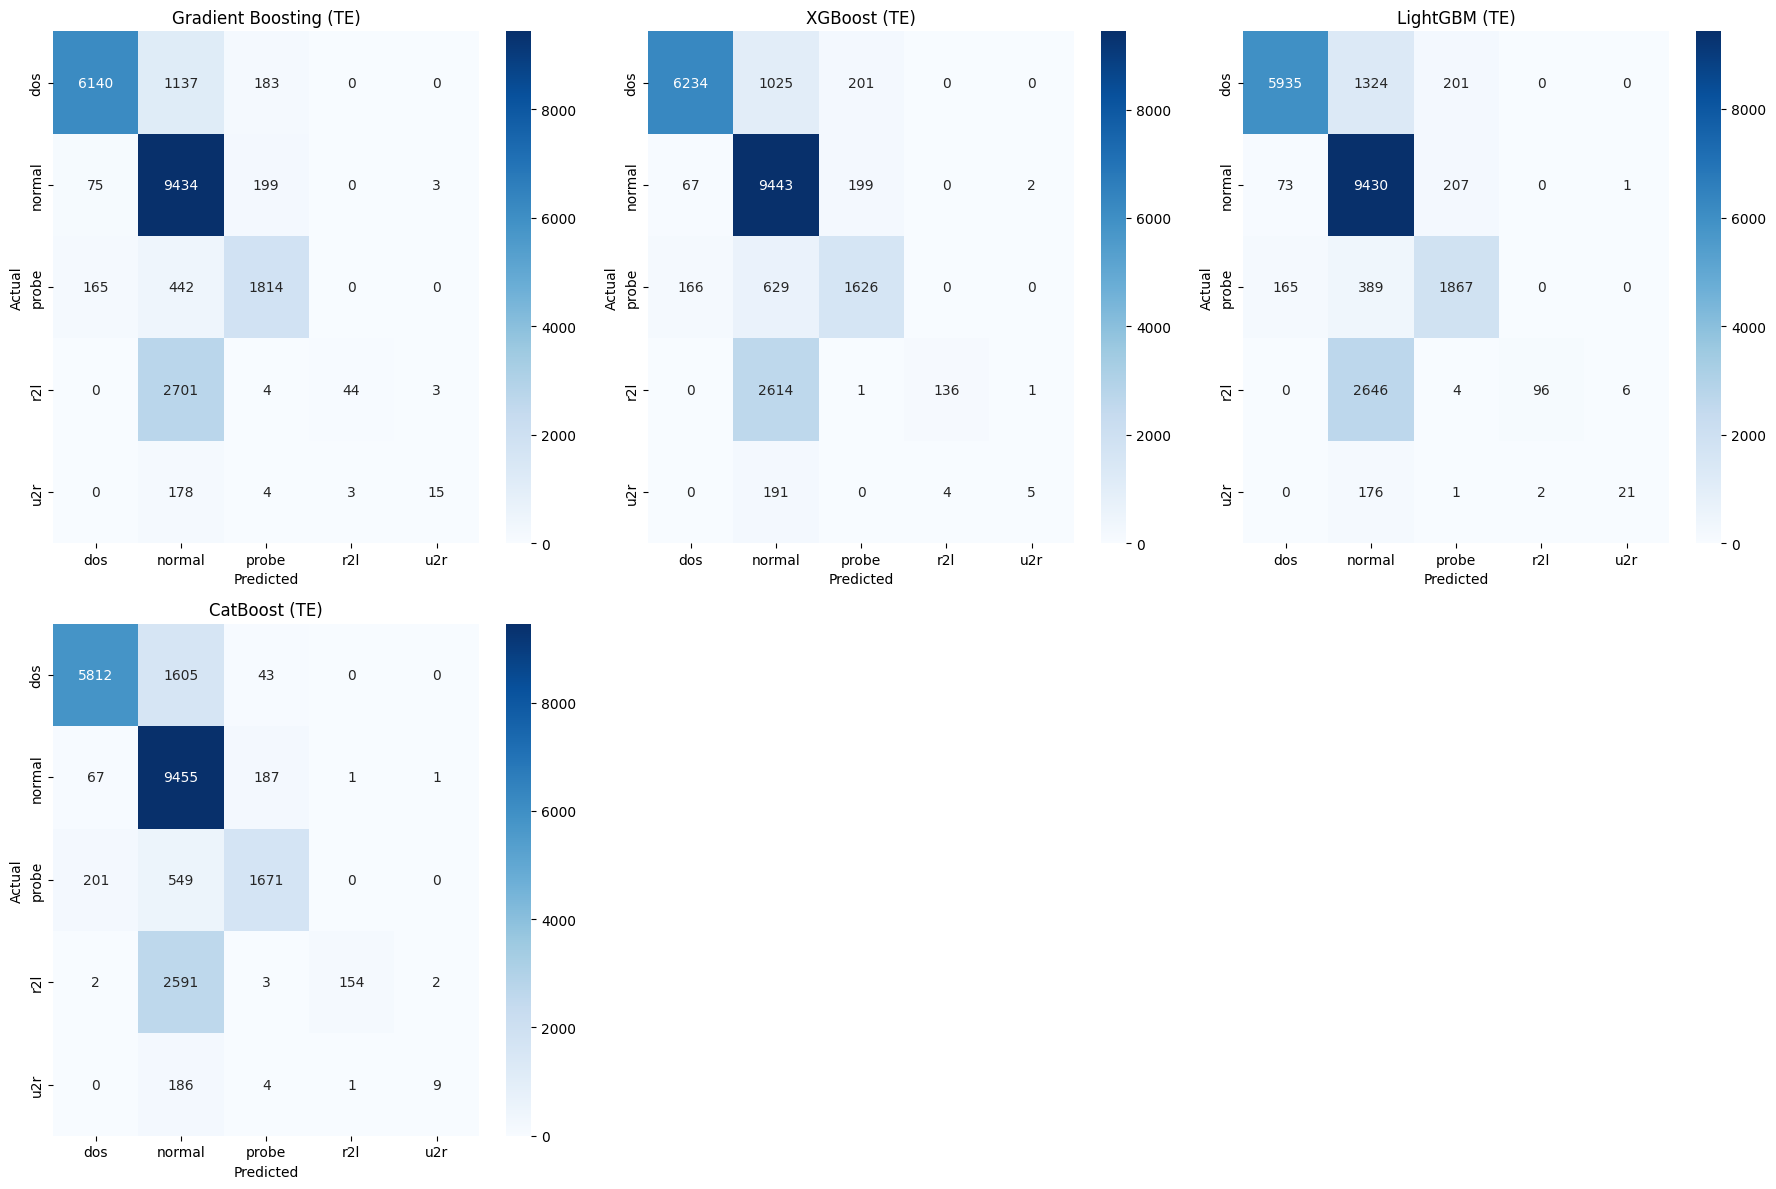

[LightGBM] [Warning] min_gain_to_split is set=0.01, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.01


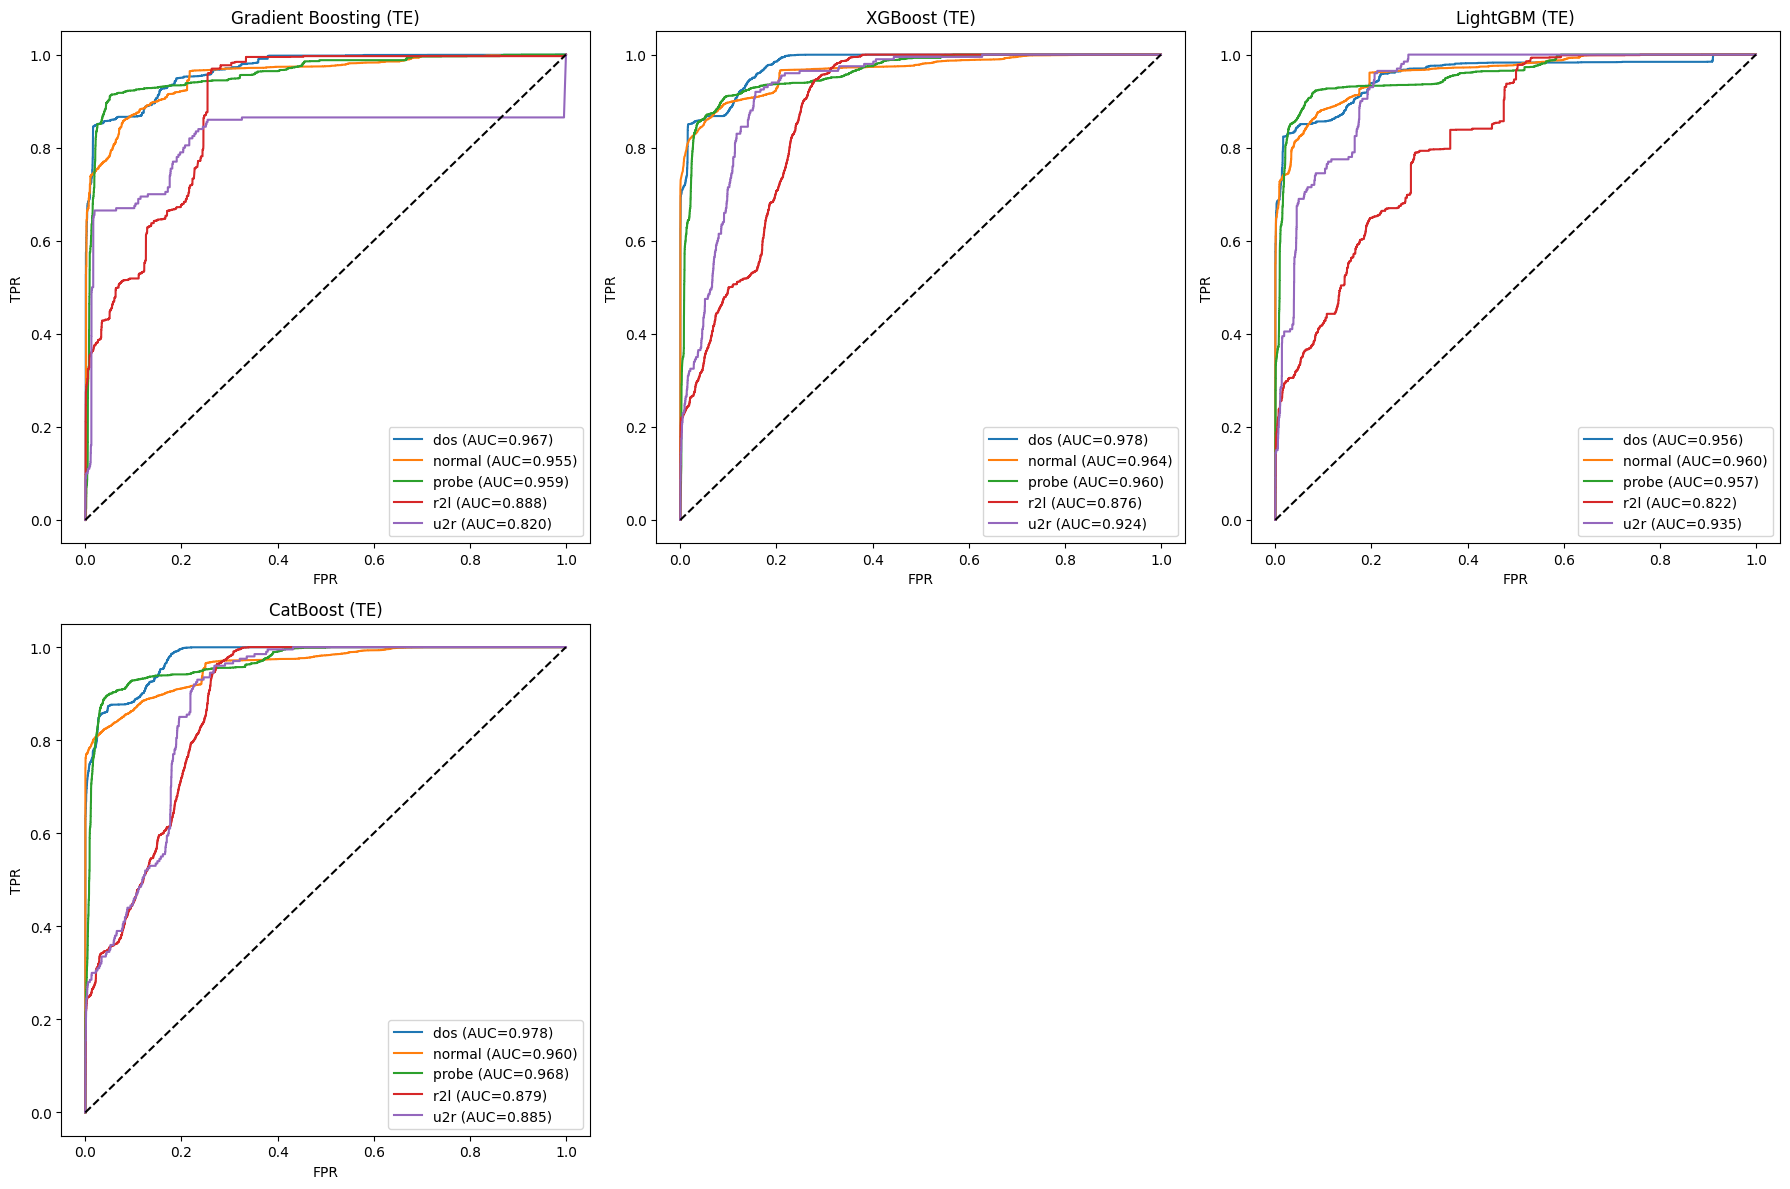

In [83]:
# ======================================================
# MULTI-CLASS CONFUSION MATRICES + ROC CURVES
# ======================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_mc(models, X, y, title, class_names):

    n = len(models)
    rows = (n + 2) // 3

    print("\n=== ", title, " ===")

    # Confusion Matrices
    plt.figure(figsize=(18, 6 * rows))
    for i, (name, model) in enumerate(models.items()):
        y_pred = model.predict(X)
        cm = confusion_matrix(y, y_pred)

        plt.subplot(rows, 3, i + 1)
        sns.heatmap(cm, annot=True, fmt="d",
                    xticklabels=class_names, yticklabels=class_names,
                    cmap="Blues")
        plt.title(name)
        plt.ylabel("Actual")
        plt.xlabel("Predicted")

    plt.tight_layout()
    plt.show()

    # ROC CURVES
    y_bin = label_binarize(y, classes=range(len(class_names)))

    plt.figure(figsize=(18, 6 * rows))
    for i, (name, model) in enumerate(models.items()):
        try:
            probs = model.predict_proba(X)
        except:
            probs = model.decision_function(X)
            if probs.ndim == 1:
                probs = probs.reshape(-1, 1)

        plt.subplot(rows, 3, i + 1)
        for c in range(len(class_names)):
            fpr, tpr, _ = roc_curve(y_bin[:, c], probs[:, c])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{class_names[c]} (AUC={roc_auc:.3f})")

        plt.plot([0, 1], [0, 1], "k--")
        plt.title(name)
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.legend()

    plt.tight_layout()
    plt.show()


# CALL PLOTTERS
plot_mc(models_OHE, X_test_mc_ohe, y_test_mc, "OHE MODELS", class_names_mc)
plot_mc(models_TE, X_test_mc_te, y_test_mc, "TARGET ENCODING MODELS", class_names_mc)


In [84]:
# ============================================================
# SAVE BINARY + MULTICLASS RESULTS INTO A JSON FILE
# ============================================================

import json

output = {
    "binary": {
        "train_metrics": train_df_metrics.to_dict(orient="records"),
        "test_metrics":  test_df_metrics.to_dict(orient="records")
    },
    "multiclass": {
        "train_metrics": train_df_mc.to_dict(orient="records"),
        "test_metrics":  test_df_mc.to_dict(orient="records")
    }
}

# Save to JSON file
output_filename = "NSL-KDD_results.json"

with open(output_filename, "w") as f:
    json.dump(output, f, indent=4)

print(f"\n Results saved to: {output_filename}")



 Results saved to: NSL-KDD_results.json
